# 🚦 Lab 2: Traffic Sign Classification & Experiment Management
### ELEC5308 – Intelligent Information Engineering Practice
**University of Sydney | School of Electrical and Computer Engineering**

---

## 🎯 Lab Objectives
By the end of this lab you will be able to:
1. **Load and explore** the GTSRB traffic-sign dataset (43 classes, ~52 k images).
2. **Implement data preprocessing** pipelines with augmentation transforms.
3. **Construct a CNN** from building blocks (`ConvBlock`, `ResidualBlock`) provided in the `elec5308` package.
4. **Train your model** and log metrics to a **CometML** experiment dashboard.
5. **Evaluate** your classifier using accuracy, precision, recall, F1 (macro / micro / weighted) and a confusion matrix.
6. **Fine-tune a pretrained ResNet** using transfer learning and compare experiments in CometML.

---

## 📦 Repository Structure
```
lab2-elec5308/
├── elec5308/               ← Python package (provided – do NOT modify)
│   ├── datasets.py         ← GTSRB loader & class registry
│   ├── models.py           ← ConvBlock, ResidualBlock, SimpleCNN, get_pretrained_resnet
│   ├── metrics.py          ← compute_metrics, plot_confusion_matrix
│   ├── trainer.py          ← Trainer class with CometML hooks
│   └── visualisation.py   ← Plotting utilities
├── lab2_notebook.ipynb    ← THIS file – your working lab notebook
└── README.md               ← This file :-)
```

> **Assessment:** This lab contributes to **Lab Milestones (5%)** and the **Lab Quiz (10%)**.  
> Submit via GitHub before the deadline shown on Canvas.  
> If you use AI tools, you **must** complete proper AI Journal entries.


---
## Section 0 — Environment Setup ✅ *Provided – just run all cells in this section*

This section installs dependencies, configures your device, and initialises
a **CometML** experiment that will track every metric you log during training.

> **What is CometML?**  
> CometML is an MLOps platform that automatically tracks your experiments:
> hyperparameters, metrics, code, and model artefacts.  
> Think of it as a lab notebook that never loses data.


In [7]:
# Install / upgrade required packages
# You could also install these packages manually using pip, e.g.:
# %pip install torch torchvision comet-ml scikit-learn matplotlib seaborn pandas tqdm torchinfo
# However, on Gradescope, %pip installs are skipped.
import subprocess, sys
packages = [
    "torch torchvision",
    "comet-ml",
    "scikit-learn",
    "matplotlib seaborn",
    "pandas tqdm",
    "torchinfo",
]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkg.split())
print("All packages installed.")

All packages installed.


In [8]:
# Importing required libraries
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader

from sklearn.metrics import ConfusionMatrixDisplay

# Let's import our custom library for this lab
# It provides functions for loading the GTSRB dataset, defining CNN models, training, and evaluation.
# Try to use those functions for your Assignment 1.
import sys; sys.path.insert(0, "..")  # Allow import from repo root
from elec5308 import (
    GTSRBDataset, load_gtsrb, GTSRB_CLASSES, NUM_CLASSES, get_class_name,
    ConvBlock, ResidualBlock, SimpleCNN, get_pretrained_resnet, count_parameters,
    compute_metrics, plot_confusion_matrix, classification_report_df,
    Trainer,
    show_sample_images, plot_class_distribution, plot_training_history,
)

# Lab computers have GPUs, but if you're running this notebook on your own computer,
# you may not have a GPU. If you are running this notebook on Colab, you can enable
# GPU acceleration by going to "Runtime" -> "Change runtime type" and selecting
# "GPU" as the hardware accelerator. However, note that on Colab, you need to install
# the elec5308 library, as simple as a `git clone URL` command. Ask Ali or your
# lab demonstrator for help if you want to run this notebook on Colab.
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():   # Apple Silicon
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print(f"Using device: {DEVICE}")
print(f"GTSRB has {NUM_CLASSES} traffic-sign classes")


Using device: cpu
GTSRB has 43 traffic-sign classes


### 0.1 — CometML Setup

Follow these steps **before running the cell below**:

1. Go to [comet.ml](https://www.comet.ml) → create a **free** account (You can use any email address).
2. Navigate to **Settings → API Keys** → copy your key.
3. Paste it into the cell below where it says `"YOUR_API_KEY_HERE"`.
4. Set your `workspace` to your CometML username.

> 💡 **Pro Tip:** Store your API key as an environment variable (`COMET_API_KEY`) instead of hard-coding it.  In a terminal: `export COMET_API_KEY="your-key"`. You can also store it inside a `.env` file. [Read more](https://help.openai.com/en/articles/5112595-best-practices-for-api-key-safety)


In [9]:
# This block shows you the full CometML setup pattern.
# You will replicate this for the Transfer Learning task (Section 6).

import comet_ml
# Option A: read from environment variable (recommended)
COMET_API_KEY  = "UQCpSYwl3lIVXNlqwA8g1KTr3" # os.environ.get("COMET_API_KEY", "YOUR_API_KEY_HERE")
COMET_PROJECT  = "elec5308-lab2"
COMET_WORKSPACE = "jiaxing-xie"   # ← replace with your Comet username

experiment = comet_ml.Experiment(
    api_key=COMET_API_KEY,
    project_name=COMET_PROJECT,
    workspace=COMET_WORKSPACE,
    auto_param_logging=True,
    auto_metric_logging=False,  # We log manually for full control
)

# Tag this experiment for easy filtering in the dashboard
experiment.add_tags(["lab2", "baseline-cnn", "gtsrb"])
experiment.set_name("SimpleCNN-baseline")

print("CometML experiment created!")
print(f"View at: {experiment.url}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/jiaxing-xie/elec5308-lab2/f37c98a898ce44eea2248345df0664eb



CometML experiment created!
View at: https://www.comet.com/jiaxing-xie/elec5308-lab2/f37c98a898ce44eea2248345df0664eb


### 0.2 — Load the GTSRB Dataset ✅

The dataset downloads automatically on first run (~300 MB).  
Subsequent runs use the cached version.


In [12]:
# Load raw dataset for exploration
gtsrb = GTSRBDataset(root="./data", image_size=32, use_imagenet_stats=False)

# Quick sanity check
print(f"\nTraining samples : {len(gtsrb.train_raw):,}")
print(f"Test samples     : {len(gtsrb.test_raw):,}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"\nFirst 5 class names:")
for i in range(5):
    print(f"  [{i:2d}] {get_class_name(i)}")

# Let's log this information to CometML as well
experiment.log_parameter("num_train_samples", len(gtsrb.train_raw))
experiment.log_parameter("num_test_samples", len(gtsrb.test_raw))
experiment.log_parameter("num_classes", NUM_CLASSES)

📦 Loading GTSRB dataset (image_size=32×32) …
✅ GTSRB loaded — train: 26,640 images | test: 12,630 images | classes: 43

Training samples : 26,640
Test samples     : 12,630
Number of classes: 43

First 5 class names:
  [ 0] Speed limit (20 km/h)
  [ 1] Speed limit (30 km/h)
  [ 2] Speed limit (50 km/h)
  [ 3] Speed limit (60 km/h)
  [ 4] Speed limit (70 km/h)


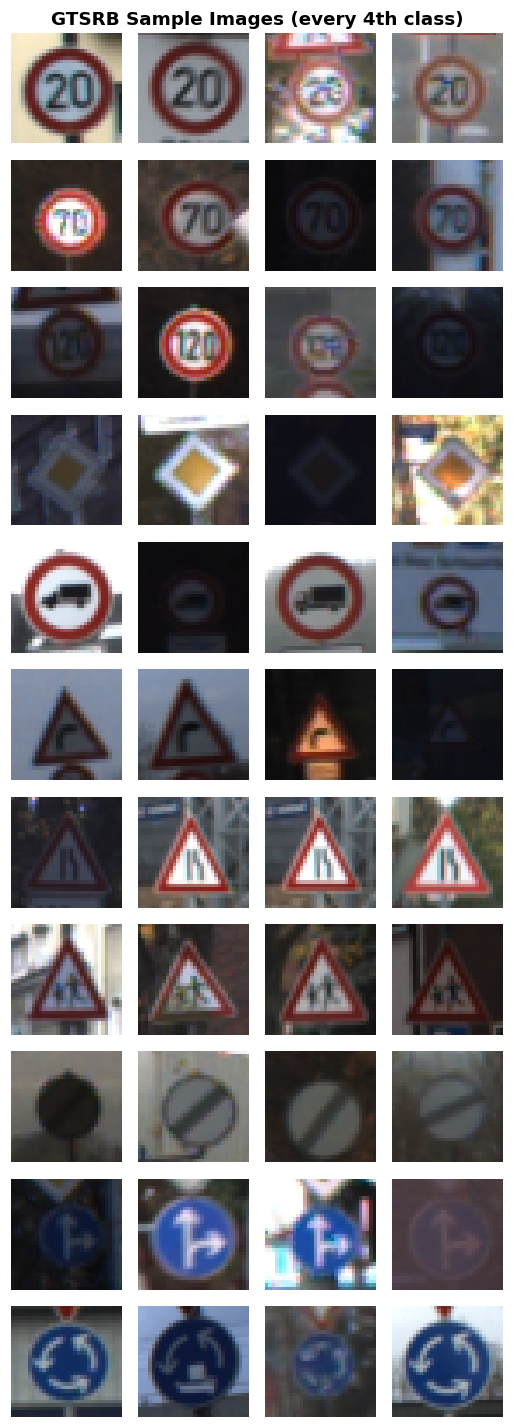

In [11]:
# shows 4 samples for a selection of 10 classes
fig = show_sample_images(
    gtsrb.train_raw,
    class_names=list(GTSRB_CLASSES.values()),
    n_per_class=4,
    classes_to_show=list(range(0, 43, 4)),   # every 4th class
    title="GTSRB Sample Images (every 4th class)",
)
# Let's log this image to CometML as well
experiment.log_figure(figure_name="GTSRB Sample Images", figure=fig)
plt.show()

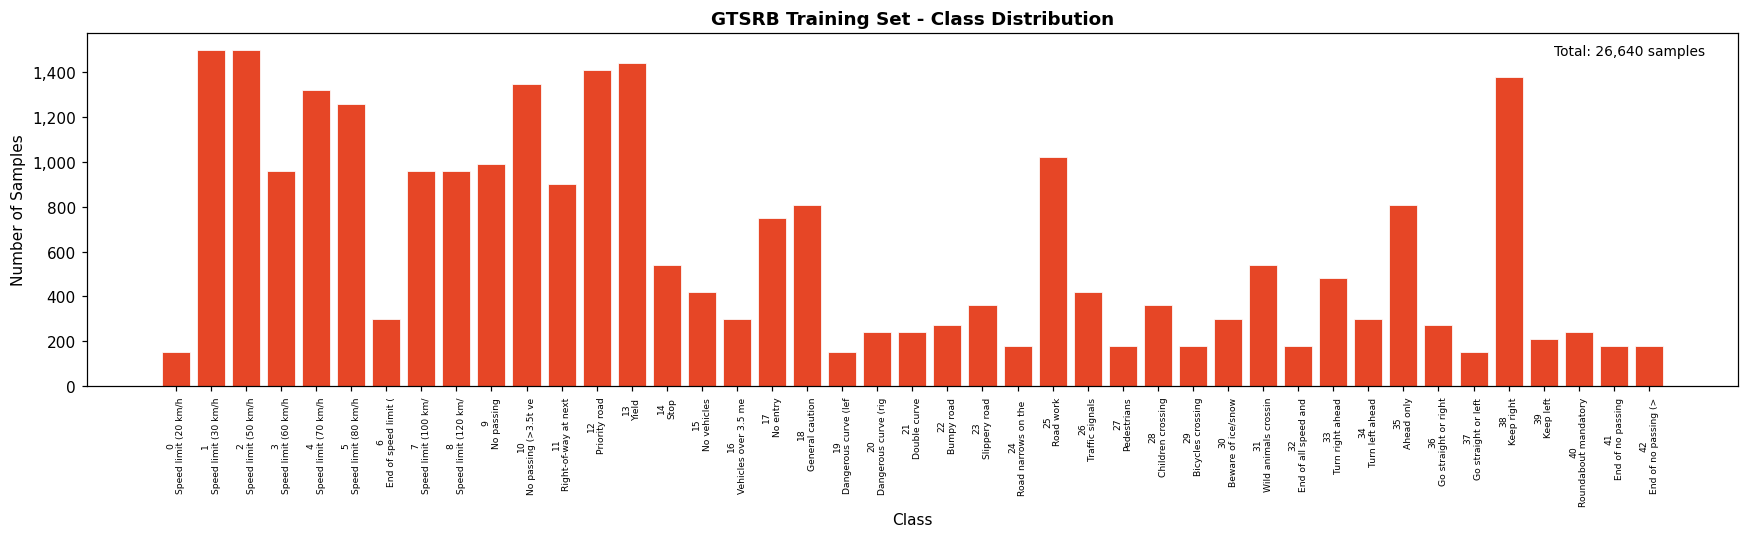


Most common class: 42 (Speed limit (30 km/h))
Rarest class     : 0 (Speed limit (20 km/h))


In [13]:
# Class distribution
train_labels = gtsrb.get_class_labels(split="train")
fig = plot_class_distribution(
    train_labels,
    class_names=list(GTSRB_CLASSES.values()),
    title="GTSRB Training Set - Class Distribution",
)
plt.show()

# Log this image to CometML
experiment.log_figure("class_distribution", fig)

print(f"\nMost common class: {train_labels.max()} ({get_class_name(int(np.bincount(train_labels).argmax()))})")
print(f"Rarest class     : {np.bincount(train_labels).argmin()} ({get_class_name(int(np.bincount(train_labels).argmin()))})")

---
## Section 2 — Task 1: Data Preprocessing 🔨 *Your turn*

### Background
Raw GTSRB images come in varying sizes.  Before feeding them to a neural
network we must:

1. **Resize** every image to a fixed spatial resolution.
2. **Normalise** pixel values so the network sees inputs in a stable range.
3. **Augment** the training set to improve generalisation (the validation and
   test sets must **not** be augmented).

Common augmentation strategies for traffic signs:
- Random horizontal/vertical flips *(caution: some signs are not symmetric!)*
- Random rotation (small angle - traffic signs are roughly upright)
- Colour jitter (brightness, contrast) - simulate day/dusk/shadow
- Random cropping / perspective distortion

> **From the lecture:** "*The true test of a model is how well it generalises to unseen examples.*"  
> Augmentation artificially expands the training distribution.

### ✏️ Your Tasks
- [ ] **2a** Define a **training transform** with at least **three augmentations**. [A comprehensive list of all available transformations](https://docs.pytorch.org/vision/main/transforms.html#v2-api-reference-recommended)
- [ ] **2b** Define a **validation/test transform** (normalise only, no augmentation).
- [ ] **2c** Create **DataLoaders** and verify the batch shape.

In [14]:
# 2a: Training Transform
# TODO: Define your training transform with at least three augmentations.
# Hint: Use torchvision.transforms (already imported as T).
#
# The normalisation statistics for GTSRB (without pretrained models) are:
#   mean = (0.3403, 0.3121, 0.3214)
#   std  = (0.2724, 0.2608, 0.2669)
#
# For pretrained models (ResNet etc.) use ImageNet stats:
#   mean = (0.485, 0.456, 0.406)
#   std  = (0.229, 0.224, 0.225)

IMAGE_SIZE = 32   # pixels - match this to your model's expected input

train_transform = T.Compose([
    # TODO: Add your augmentations here
    # Example starter (replace / extend):
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)), # small rotation
    # Add augmentations below
    # And remember, you can use AI to help you generate augmentations,
    # but you must understand them, be able to explain them, and
    # declare its usage via a proper AI journal.
    # Read more here: https://docs.pytorch.org/vision/main/transforms.html#v2-api-reference-recommended
    T.ColorJitter(brightness=0.3, contrast=0.3),     # lighting variation
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)), # small translation
    T.ToTensor(),
    T.Normalize(mean=(0.3403, 0.3121, 0.3214),
                std=(0.2724, 0.2608, 0.2669)),
])

print("Train transform defined:", train_transform)


Train transform defined: Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=None, hue=None)
    RandomAffine(degrees=[0.0, 0.0], translate=(0.1, 0.1))
    ToTensor()
    Normalize(mean=(0.3403, 0.3121, 0.3214), std=(0.2724, 0.2608, 0.2669))
)


In [15]:
# 2b: Validation / Test Transform
# TODO: Define the evaluation transform.
# Remember: NO augmentation on validation or test sets!

eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=(0.3403, 0.3121, 0.3214),
                std=(0.2724, 0.2608, 0.2669)),
])

print("Eval transform defined:", eval_transform)

Eval transform defined: Compose(
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=(0.3403, 0.3121, 0.3214), std=(0.2724, 0.2608, 0.2669))
)


In [16]:
# 2c: Create DataLoaders
# TODO: Fill in batch_size and num_workers.
# Hint: batch_size between 32 and 128 is typical.
#       num_workers=2 works well on most machines.

BATCH_SIZE  = 64   # TODO: choose a value
NUM_WORKERS = 2   # TODO: choose a value
VAL_SPLIT = 0.15   # 15% of training data held out for validation

train_loader, val_loader, test_loader = load_gtsrb(
    root="./data",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    val_fraction=VAL_SPLIT,
    train_transform=train_transform,
    eval_transform=eval_transform,
    num_workers=NUM_WORKERS,
    seed=2026,
)

# 2d: Verify batch shape
images, labels = next(iter(train_loader))
print(f"\nBatch shape  : {images.shape}  → (batch, channels, height, width)")
print(f"Labels shape : {labels.shape}")
print(f"Label range  : [{labels.min()}, {labels.max()}]  (expect [0, 42])")
assert images.ndim == 4, "Expected 4D tensor (B, C, H, W)"
assert labels.max() <= 42, "Labels should be in [0, 42]"
print("\nDataLoaders look correct!")

✅ DataLoaders ready — train: 22,644 | val: 3,996 | test: 12,630 samples

Batch shape  : torch.Size([64, 3, 32, 32])  → (batch, channels, height, width)
Labels shape : torch.Size([64])
Label range  : [1, 42]  (expect [0, 42])

DataLoaders look correct!


> **Anything important to note on the DataLoaders?** You can log them to CometML using `experiment.log_parameter()` if you think it's useful.

In [17]:
# Log batch size, validation split, and image sizes to CometML.
# These are important hyperparameters for your experiment.
# Additionally, you can log the transformations (augmentations).
experiment.log_parameter("batch_size", BATCH_SIZE)
experiment.log_parameter("val_split", VAL_SPLIT)
experiment.log_parameter("image_size", IMAGE_SIZE)
experiment.log_text(str(train_transform), metadata={"context":"data augmentation", "purpose": "train_pipeline"})
experiment.log_text(str(eval_transform), metadata={"context":"data augmentation", "purpose": "eval_pipeline"})

{'web': 'https://www.comet.com/api/asset/download?assetId=29ef95a80917426e8e2c32cd38b5fa31&experimentKey=f37c98a898ce44eea2248345df0664eb',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=29ef95a80917426e8e2c32cd38b5fa31&experimentKey=f37c98a898ce44eea2248345df0664eb',
 'assetId': '29ef95a80917426e8e2c32cd38b5fa31'}

#### Comet Dashboard

Let's look at your Comet dashboard. What is logged there?

---
## Section 3 — Task 2: Build Your CNN 🔨 *Your turn*

### Background
The `elec5308.models` module provides the following building blocks:

| Class | What it does |
|---|---|
| `ConvBlock(in_ch, out_ch, kernel_size, padding, pool)` | Conv → BN (Will be discuused in Week 3) → ReLU (→ MaxPool) |
| `ResidualBlock(in_ch, out_ch, stride)` | Skip-connection block (ResNet-style) |
| `SimpleCNN(num_classes)` | Provided baseline — 3 ConvBlocks + global average pool |

Your task is to **design your own CNN** by assembling these blocks.  You can:
- Use `SimpleCNN` as a starting point and modify it.
- Build from scratch using `ConvBlock` and `ResidualBlock`.
- Add `nn.BatchNorm2d`, `nn.Dropout`, or custom activation functions.

> **On this week's lecture:** We covered ConvBlocks, padding, stride,
> pooling, and classic architectures (LeNet → AlexNet → VGG → ResNet).

### ✏️ Your Tasks
- [ ] **3a** Design a CNN with at least **3 convolutional layers**.
- [ ] **3b** Print the model architecture and count trainable parameters.
- [ ] **3c** Verify the output shape with a dummy forward pass.


In [18]:
# 3a: Define your CNN
# TODO: Design your model.
#
# Option A – modify SimpleCNN (baseline):
#   model = SimpleCNN(num_classes=NUM_CLASSES)
#
# Option B – build from scratch:
# class MyCNN(nn.Module):
#     def __init__(self, num_classes=43):
#         super().__init__()
#         self.features = nn.Sequential(
#             ConvBlock(3, 32, pool=True),      # 32×32 → 16×16
#             ConvBlock(32, 64, pool=True),     # 16×16 → 8×8
#             ConvBlock(64, 128, pool=True),    # 8×8  → 4×4
#             ResidualBlock(128, 128),          # residual connection
#         )
#         self.head = nn.Sequential(
#             nn.AdaptiveAvgPool2d((1, 1)),
#             nn.Flatten(),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         return self.head(x)

#
# Option C – add ResidualBlocks for extra marks:
#   model = nn.Sequential(
#       ConvBlock(3, 64, pool=True),
#       ResidualBlock(64, 128, stride=2),
#       ...
#   )
class MyCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, kernel_size=3, padding=1, pool=True),   # 32 → 16
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 128, stride=2),   # 16 → 8
            ResidualBlock(128, 128, stride=1),
            ResidualBlock(128, 256, stride=2),  # 8 → 4
            ResidualBlock(256, 256, stride=1),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),   # 256
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)



model = MyCNN(num_classes=NUM_CLASSES).to(DEVICE) # ← replace with your model
assert model is not None, "Please define your model!"
print(model)


MyCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ResidualBlock(
      (conv_stack): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (shortcut): Sequential()
      (relu): ReLU(inplace=True)
    )
    (2): ResidualBlock(
      (conv_

In [20]:
# 3b: Count parameters
n_params = count_parameters(model)
print(f"Trainable parameters: {n_params:,}")

# Log architecture to CometML
experiment.log_parameter("model_trainable_params", n_params)
experiment.log_parameter("model_name", type(model).__name__)
experiment.log_parameter("model_architecture", str(model))


COMET WARNING: String value length exceeds 1000 characters and will be truncated. Provided value: 'MyCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ResidualBlock(
      (conv_stack): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
      (

Trainable parameters: 2,712,171


> Did you notice that model definition is truncated as it exceeds 1000 characters? A more proper way is to log the code used to generate the model.

In [21]:
import inspect

# 1. Extract the exact source code of the class
model_class_code = ''' 
class MyCNN(nn.Module):
    def __init__(self, num_classes=43):
        super().__init__()
        self.features = nn.Sequential(
            ConvBlock(3, 64, kernel_size=3, padding=1, pool=True),   # 32 → 16
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 128, stride=2),   # 16 → 8
            ResidualBlock(128, 128, stride=1),
            ResidualBlock(128, 256, stride=2),  # 8 → 4
            ResidualBlock(256, 256, stride=1),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),   # 256
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)
'''

# 2. Log the text block to Comet (it will appear under the Text tab)
experiment.log_code(code=model_class_code, code_name="cnn model")

[('cnn model',
  {'web': 'https://www.comet.com/api/asset/download?assetId=f93c24d189504244bdfe38099c0e84ec&experimentKey=f37c98a898ce44eea2248345df0664eb',
   'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=f93c24d189504244bdfe38099c0e84ec&experimentKey=f37c98a898ce44eea2248345df0664eb',
   'assetId': 'f93c24d189504244bdfe38099c0e84ec'})]

In [22]:
# 3c: Verify output shape with a dummy input
dummy = torch.randn(4, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f"Input  shape: {dummy.shape}")
print(f"Output shape: {out.shape}  ← should be (4, {NUM_CLASSES})")
assert out.shape == (4, NUM_CLASSES), f"Expected output shape (4, {NUM_CLASSES}), got {out.shape}"
print("Model output shape is correct!")

Input  shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 43])  ← should be (4, 43)
Model output shape is correct!


---
## Section 4 — Task 3: Train Your Model 🔨 *Your turn*

### Background
Training a neural network involves three steps per mini-batch:
1. **Forward pass** – compute predictions.
2. **Loss** – measure how wrong the predictions are (cross-entropy loss).
3. **Backward pass** – compute gradients and update weights (gradient descent).

The `Trainer` class in `elec5308.trainer` handles this loop and automatically
logs metrics to your CometML experiment.

> **In the lecture**, we covered gradient descent, and learning rate.

### ✏️ Your Tasks
- [ ] **4a** Choose a loss function and optimiser; log hyperparameters to CometML.
- [ ] **4b** Train for at least 15 epochs using the `Trainer`.
- [ ] **4c** Plot the training history and interpret the curves and log it into Comet.


In [23]:
# 4a: Loss function and optimiser
# TODO: Choose appropriate loss function and optimiser.
# Hint:
#   - Multi-class classification → nn.CrossEntropyLoss()
#   - Good default optimiser    → torch.optim.Adam
#   - Typical learning rates    → 1e-3 to 1e-4

LEARNING_RATE = 1e-3   # TODO
WEIGHT_DECAY  = 1e-4   # TODO (e.g. 1e-4)
N_EPOCHS      = 20   # TODO (at least 15)

criterion = nn.CrossEntropyLoss()   # TODO: define loss function, e.g. nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)   # TODO: define optimiser, e.g. torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

assert criterion is not None, "Define a loss function"
assert optimiser is not None, "Define an optimiser"

# Log hyperparameters to CometML
experiment.log_parameters({
    "learning_rate": LEARNING_RATE,
    "weight_decay":  WEIGHT_DECAY,
    "n_epochs":      N_EPOCHS,
    "batch_size":    BATCH_SIZE,
    "image_size":    IMAGE_SIZE,
    "val_split":     VAL_SPLIT,
    "optimizer":     type(optimiser).__name__,
    "loss_function": type(criterion).__name__,
})
print("Hyperparameters logged to CometML")


Hyperparameters logged to CometML


> It's a good idea to see how this information is displayed in your Comet dashboard

In [24]:
# 4b: Train using Trainer

# Optional: add a learning-rate scheduler for smoother training
# scheduler = torch.optim.lr_scheduler.StepLR(optimiser, step_size=5, gamma=0.5)

trainer = Trainer(
    model=model,
    optimiser=optimiser,
    criterion=criterion,
    device=DEVICE,
    experiment=experiment,      # ← CometML experiment for automatic logging
    checkpoint_dir="./checkpoints",
)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=N_EPOCHS,
    # scheduler=scheduler,    # uncomment if using a scheduler (Will be discussed on Week 4)
    save_best=True,
)

# Restore the best model weights
# Yes, this is important! The model at the end of training may
# not be the best one, due to overfitting.
trainer.load_best()



🚀  Starting training on cpu for 20 epochs



  train:   0%|          | 0/354 [00:08<?, ?it/s]

  eval :   0%|          | 0/63 [00:08<?, ?it/s]

Epoch   1/20 | train loss 2.0776  acc 0.3884 | val loss 0.8780  acc 0.7160 | 102.0s ✨ best


  train:   0%|          | 0/354 [00:08<?, ?it/s]

...

  eval :   0%|          | 0/63 [00:08<?, ?it/s]

Epoch  19/20 | train loss 0.0289  acc 0.9924 | val loss 0.0086  acc 0.9975 | 102.6s ✨ best


  train:   0%|          | 0/354 [00:08<?, ?it/s]

  eval :   0%|          | 0/63 [00:08<?, ?it/s]

Epoch  20/20 | train loss 0.0316  acc 0.9915 | val loss 0.0228  acc 0.9937 | 103.6s

✅  Training complete.  Best val accuracy: 0.9975
✅  Loaded best model weights (val_acc=0.9975)


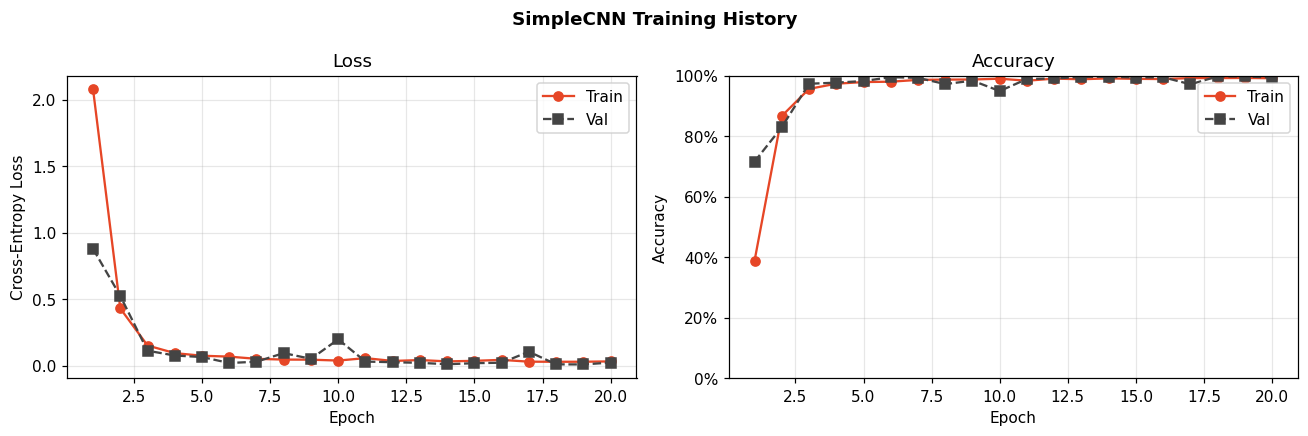


Final train loss : 0.0316
Final train acc  : 99.15%
Final val loss   : 0.0228
Final val acc    : 99.37%


In [25]:
# 4c: Plot training history
fig = plot_training_history(history, title="SimpleCNN Training History")
plt.show()

# Log the figure to CometML
experiment.log_figure("training_curves", fig)

# Final metrics summary
print(f"\nFinal train loss : {history['train_loss'][-1]:.4f}")
print(f"Final train acc  : {history['train_acc'][-1]:.2%}")
print(f"Final val loss   : {history['val_loss'][-1]:.4f}")
print(f"Final val acc    : {history['val_acc'][-1]:.2%}")


> Did you know that some of the training parameters are automatically logged in Comet? We're handling those behind the scene in ELEC5308 Python package.
>
> Want to learn more? The source code is waiting for you! And you can always ask us for help!

---
## Section 5 — Task 4: Evaluate Your Model 🔨 *Your turn*

### Background
Accuracy alone is misleading for **imbalanced datasets** like GTSRB (some
classes have 10× more samples than others).  You must also report:

| Metric | When it matters |
|---|---|
| **Macro F1** | Detects failure on rare classes |
| **Weighted F1** | Best summary for imbalanced overall performance |
| **Confusion Matrix** | Reveals which sign pairs are most confused |

> **In the Lecture** we covered accuracy, precision, recall,
> F1, micro vs macro vs weighted averages.

### ✏️ Your Tasks
- [ ] **5a** Evaluate your trained model on the **test set**.
- [ ] **5b** Plot the confusion matrix.
- [ ] **5c** Compute and display all metrics; log them to CometML.
- [ ] **5d** Identify the top 5 most confused class pairs.


In [26]:
# 5a: Evaluate on test set
test_loss, test_acc, test_preds, test_labels = trainer.evaluate(test_loader)

print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.2%}")

# Log to CometML
experiment.log_metric("test_loss", test_loss)
experiment.log_metric("test_accuracy", test_acc)


  eval :   0%|          | 0/198 [00:09<?, ?it/s]

Test loss    : 0.0980
Test accuracy: 96.98%


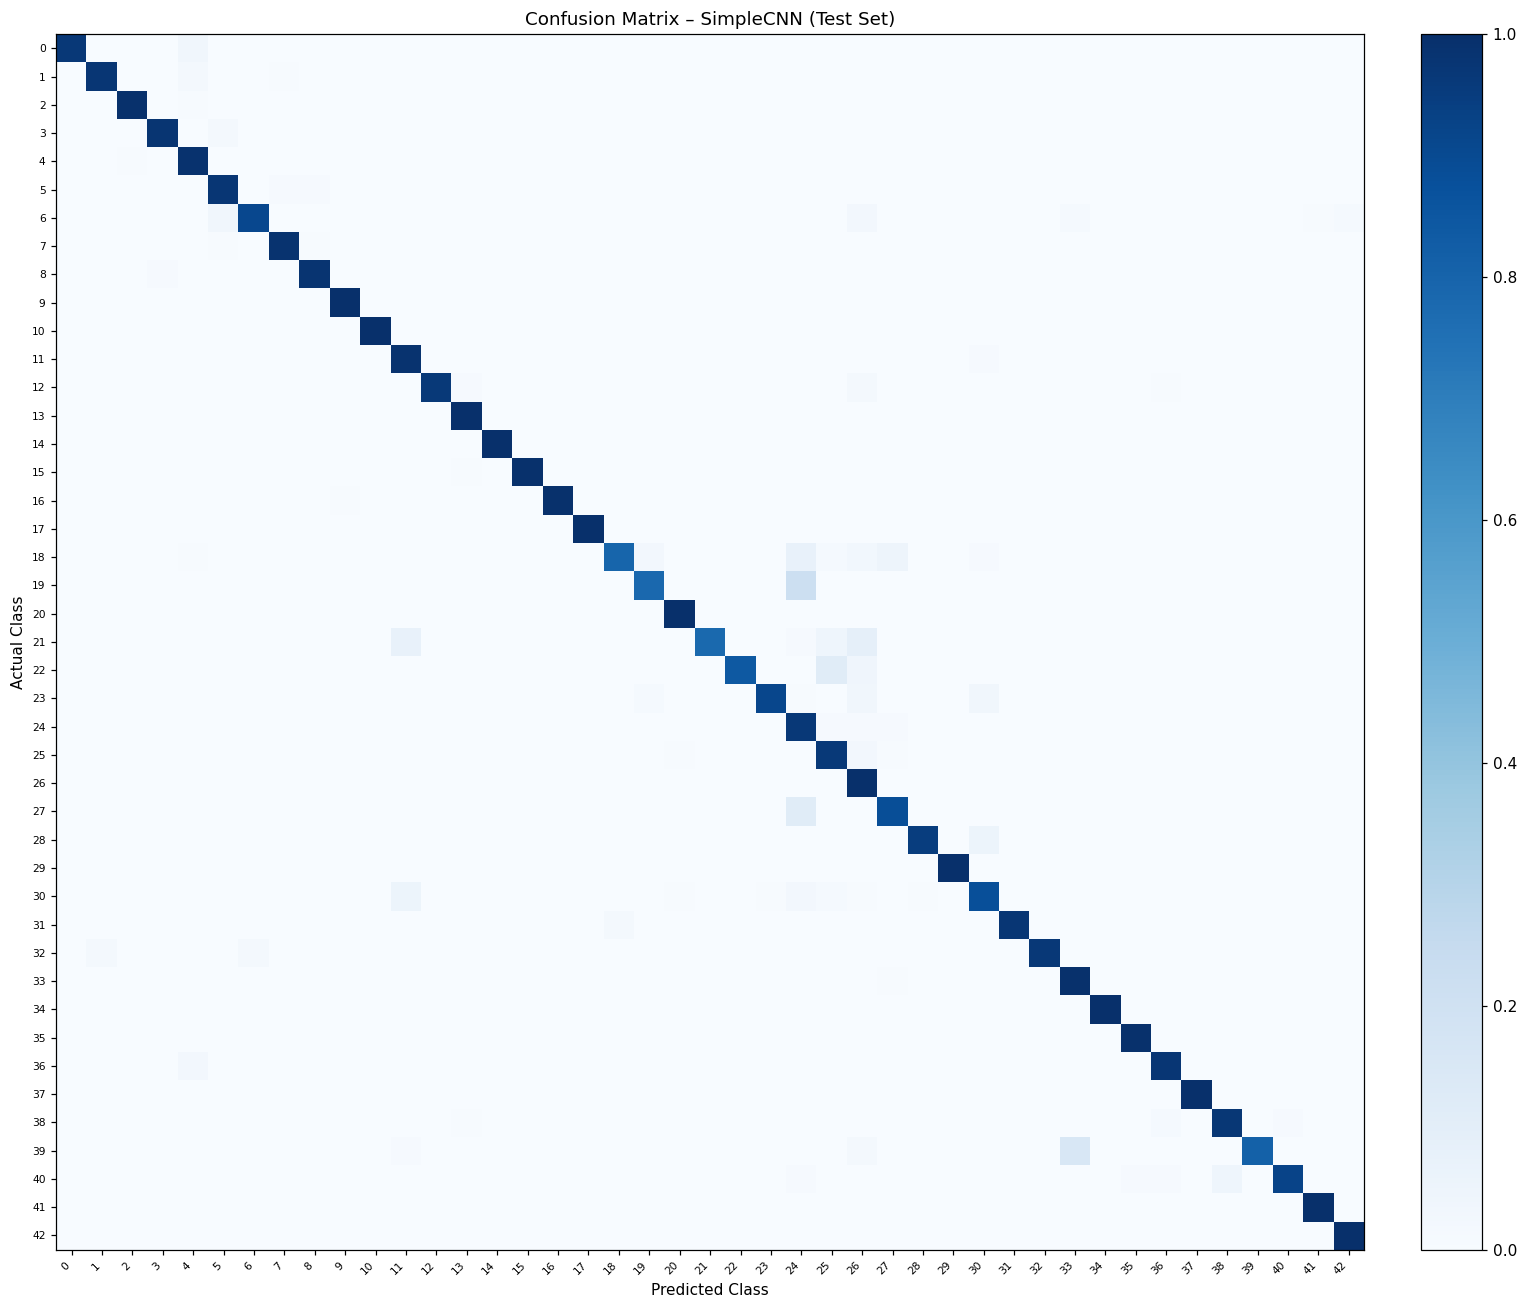

{'web': 'https://www.comet.com/api/asset/download?assetId=53aec9c8c82d4f5d92c6ac44b20056a0&experimentKey=f37c98a898ce44eea2248345df0664eb',
 'api': 'https://www.comet.com/api/rest/v2/experiment/asset/get-asset?assetId=53aec9c8c82d4f5d92c6ac44b20056a0&experimentKey=f37c98a898ce44eea2248345df0664eb',
 'assetId': '53aec9c8c82d4f5d92c6ac44b20056a0'}

In [27]:
# 5b: Confusion matrix
# TODO: Compute and plot the confusion matrix.
# Hint: use compute_metrics() from elec5308 to get the confusion matrix,
#       then pass it to plot_confusion_matrix().

metrics = compute_metrics(
    y_true=test_labels,      # TODO: pass test_labels
    y_pred=test_preds,      # TODO: pass test_preds
    num_classes=NUM_CLASSES,
)

cm = metrics["confusion_matrix"]

# Plot
class_names_short = [f"{i}" for i in range(NUM_CLASSES)]  # short labels for readability
fig_cm = plot_confusion_matrix(
    cm,
    class_names=class_names_short,
    normalise=True,
    title="Confusion Matrix – SimpleCNN (Test Set)",
)
experiment.log_figure("confusion_matrix", fig_cm)
plt.show()

# A better way to log confusion matrix
experiment.log_confusion_matrix(
    y_true=test_labels,
    y_predicted=test_preds,
    labels=class_names_short,
    title="Confusion Matrix – SimpleCNN (Test Set)",
)

In [28]:
# 5c: Print all metrics
print("=" * 55)
print(f"{'Metric':<30} {'Value':>10}")
print("=" * 55)
print(f"{'Accuracy':<30} {metrics['accuracy']:>10.4f}")
print("-" * 55)
for avg in ["macro", "micro", "weighted"]:
    print(f"{'Precision (' + avg + ')':<30} {metrics['precision_' + avg]:>10.4f}")
    print(f"{'Recall (' + avg + ')':<30} {metrics['recall_' + avg]:>10.4f}")
    print(f"{'F1-Score (' + avg + ')':<30} {metrics['f1_' + avg]:>10.4f}")
    print("-" * 55)

# Log all scalar metrics to CometML
experiment.log_metrics({
    "test_accuracy":        metrics["accuracy"],
    "test_f1_macro":        metrics["f1_macro"],
    "test_f1_micro":        metrics["f1_micro"],
    "test_f1_weighted":     metrics["f1_weighted"],
    "test_precision_macro": metrics["precision_macro"],
    "test_recall_macro":    metrics["recall_macro"],
})


Metric                              Value
Accuracy                           0.9698
-------------------------------------------------------
Precision (macro)                  0.9539
Recall (macro)                     0.9545
F1-Score (macro)                   0.9513
-------------------------------------------------------
Precision (micro)                  0.9698
Recall (micro)                     0.9698
F1-Score (micro)                   0.9698
-------------------------------------------------------
Precision (weighted)               0.9734
Recall (weighted)                  0.9698
F1-Score (weighted)                0.9703
-------------------------------------------------------


In [29]:
# 5d: Per-class report and most confused pairs
from elec5308.metrics import top_confused_pairs, classification_report_df

# Per-class F1 scores
report_df = classification_report_df(
    test_labels, test_preds,
    class_names=list(GTSRB_CLASSES.values()),
)
print("\nPer-class Classification Report (top 10 by support):")
display(report_df.sort_values("support", ascending=False).head(10))

# Most confused pairs
confused = top_confused_pairs(cm, class_names=list(GTSRB_CLASSES.values()), k=10)
print("\nTop 10 Most Confused Class Pairs:")
display(confused)



Per-class Classification Report (top 10 by support):


,precision,recall,f1-score,support
class,,,,
weighted avg,0.9734,0.9698,0.9703,12630.0
macro avg,0.9539,0.9545,0.9513,12630.0
Speed limit (50 km/h),0.9907,0.9933,0.9920,750.0
Speed limit (30 km/h),0.9929,0.9750,0.9839,720.0
Yield,0.9849,0.9986,0.9917,720.0
Keep right,0.9896,0.9696,0.9795,690.0
Priority road,1.0000,0.9638,0.9815,690.0
No passing (>3.5t vehicles),0.9970,0.9985,0.9977,660.0
Speed limit (70 km/h),0.9617,0.9894,0.9754,660.0



Top 10 Most Confused Class Pairs:


,actual,predicted,count
0,General caution,Road narrows on the right,28
1,General caution,Pedestrians,19
2,Keep left,Turn right ahead,14
3,Bumpy road,Road work,14
4,Speed limit (30 km/h),Speed limit (70 km/h),13
5,Dangerous curve (left),Road narrows on the right,13
6,General caution,Traffic signals,12
7,Road work,Traffic signals,12
8,Priority road,Traffic signals,11
9,General caution,Dangerous curve (left),10


---
## Section 6 — Task 5: Transfer Learning 🌟 *Optional task*

### Background
Instead of training from scratch, **transfer learning** reuses features learned
from a large dataset (ImageNet, 1.2 M images) and adapts them to GTSRB.

Strategy:
1. Load a ResNet-18 pretrained on ImageNet.
2. **Freeze** the convolutional backbone (don't update those weights initially).
3. Only train the final fully-connected layer.
4. (Optional) After convergence, **unfreeze** the entire network and fine-tune
   at a very low learning rate.

> **In the lecture**, we covered transfer learning, freezing
> strategies, and why pre-trained features generalise.

### ✏️ Your Tasks
- [ ] **6a** Load a pretrained ResNet-18 with a GTSRB head.
- [ ] **6b** Create a NEW CometML experiment for this run.
- [ ] **6c** Train with a larger `image_size=64` and ImageNet normalisation.
- [ ] **6d** Compare both experiments in the CometML dashboard.

In [36]:
# 6a: Load pretrained ResNet-18
# TODO: Use get_pretrained_resnet() to load the model.
# Hint: set freeze_backbone=True initially.

resnet_model = get_pretrained_resnet(
    num_classes=NUM_CLASSES,
    freeze_backbone=False,      # freeze early layers first
).to(DEVICE)

print(resnet_model)
print(f"Trainable parameters: {count_parameters(resnet_model):,}")

🏗  resnet18 loaded — trainable params: 11,198,571 / 11,198,571 (full fine-tune)
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): Ba

In [37]:
# 6b: New CometML experiment
# TODO: Create a new CometML experiment for this transfer learning run.
# Pattern: same as Section 0, but with a different experiment name.
experiment_tl = comet_ml.Experiment(
    api_key=COMET_API_KEY,
    project_name=COMET_PROJECT,
    workspace=COMET_WORKSPACE,
    auto_param_logging=True,
    auto_metric_logging=False,
) # TODO: comet_ml.Experiment(...)
assert experiment_tl is not None, "Create a new CometML experiment"
# Note that we are using a different experiment name and
# tags for this transfer learning experiment.
experiment_tl.add_tags(["lab2", "transfer-learning", "resnet18", "gtsrb"])
experiment_tl.set_name("ResNet18-TransferLearning")

print("Transfer Learning experiment created!")
print(f"View at: {experiment_tl.url}")

COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : ResNet18-TransferLearning
COMET INFO:     url                   : https://www.comet.com/jiaxing-xie/elec5308-lab2/fe8296a79eac496594eeea9dc0b0a9ae
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     train_acc [20]  : (0.38813813813813813, 0.5635488429606077)
COMET INFO:     train_loss [20] : (1.394849257257755, 2.1083782935306767)
COMET INFO:     val_acc [20]    : (0.45995995995996, 0.5755755755755756)
COMET INFO:     val_loss [20]   : (1.4094918553416316, 1.7610621473810695)
COMET INFO:   Others:
COMET INFO:     Name : ResNet18-Tr

Transfer Learning experiment created!
View at: https://www.comet.com/jiaxing-xie/elec5308-lab2/35ba6a222ba846c8835dd41a2df5d625


In [38]:
# 6c: DataLoaders with ImageNet normalisation
# TODO: Create new DataLoaders for a larger image_size=64 and ImageNet stats.
IMAGE_SIZE_TL  = 64    # ResNet was trained on 224×224 but 64 works for lab speed
LR_TL          = 1e-3  # TODO: try 1e-3 for frozen backbone
N_EPOCHS_TL    = 15  # TODO: 10–15 epochs

train_transform_tl = T.Compose([
    T.Resize((IMAGE_SIZE_TL, IMAGE_SIZE_TL)),
    # TODO: Add augmentations
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
])

eval_transform_tl = T.Compose([
    T.Resize((IMAGE_SIZE_TL, IMAGE_SIZE_TL)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
])

train_loader_tl, val_loader_tl, test_loader_tl = load_gtsrb(
    root="./data",
    image_size=IMAGE_SIZE_TL,
    batch_size=32,
    train_transform=train_transform_tl,
    eval_transform=eval_transform_tl,
    use_imagenet_stats=True,
)

# Log hyperparameters
experiment_tl.log_parameters({
    "backbone": "resnet18",
    "freeze_backbone": True,
    "image_size": IMAGE_SIZE_TL,
    "n_epochs": N_EPOCHS_TL,
    "learning_rate": LR_TL,
})

✅ DataLoaders ready — train: 22,644 | val: 3,996 | test: 12,630 samples


In [39]:
# Train the transfer learning model
# TODO: Create optimiser, Trainer, and call .fit()

criterion_tl = nn.CrossEntropyLoss()
optimiser_tl = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet_model.parameters()),
    lr=LR_TL,
    weight_decay=1e-4
)

trainer_tl = Trainer(
    model=resnet_model,
    optimiser=optimiser_tl,
    criterion=criterion_tl,
    device=DEVICE,
    experiment=experiment_tl,
    checkpoint_dir="./checkpoints/resnet",
)

history_tl = trainer_tl.fit(
    train_loader=train_loader_tl,
    val_loader=val_loader_tl,
    epochs=N_EPOCHS_TL,
    save_best=True,
)
trainer_tl.load_best()


🚀  Starting training on cpu for 15 epochs



  train:   0%|          | 0/708 [00:09<?, ?it/s]

  eval :   0%|          | 0/125 [00:09<?, ?it/s]

Epoch   1/15 | train loss 0.6724  acc 0.7964 | val loss 0.2454  acc 0.9227 | 290.2s ✨ best


  train:   0%|          | 0/708 [00:09<?, ?it/s]

...

  eval :   0%|          | 0/125 [00:09<?, ?it/s]

Epoch  14/15 | train loss 0.0577  acc 0.9850 | val loss 0.0129  acc 0.9965 | 277.1s ✨ best


  train:   0%|          | 0/708 [00:09<?, ?it/s]

  eval :   0%|          | 0/125 [00:09<?, ?it/s]

Epoch  15/15 | train loss 0.0464  acc 0.9881 | val loss 0.0119  acc 0.9967 | 275.6s ✨ best

✅  Training complete.  Best val accuracy: 0.9967
✅  Loaded best model weights (val_acc=0.9967)


### Transfer Learning Result Note

Initially, I set `freeze_backbone=True` and trained only the classifier head.  
The test accuracy was only **56%**, which was significantly lower than expected.

After changing `freeze_backbone=False` (allowing the entire network to be fine-tuned) and increasing the number of epochs, the model performance improved substantially.

In [40]:
# 6d: Evaluate transfer learning model and compare
tl_loss, tl_acc, tl_preds, tl_labels = trainer_tl.evaluate(test_loader_tl)
tl_metrics = compute_metrics(tl_labels, tl_preds, num_classes=NUM_CLASSES)

experiment_tl.log_metrics({
    "test_accuracy":    tl_metrics["accuracy"],
    "test_f1_macro":    tl_metrics["f1_macro"],
    "test_f1_weighted": tl_metrics["f1_weighted"],
})
experiment_tl.end()

print("\nModel Comparison")
print("=" * 45)
print(f"{'Metric':<20} {'SimpleCNN':>10} {'ResNet-TL':>10}")
print("-" * 45)
print(f"{'Test Accuracy':<20} {test_acc:>10.2%} {tl_acc:>10.2%}")
print(f"{'F1 Macro':<20} {metrics['f1_macro']:>10.4f} {tl_metrics['f1_macro']:>10.4f}")
print(f"{'F1 Weighted':<20} {metrics['f1_weighted']:>10.4f} {tl_metrics['f1_weighted']:>10.4f}")
print("=" * 45)

  eval :   0%|          | 0/395 [00:09<?, ?it/s]

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : ResNet18-TransferLearning
COMET INFO:     url                   : https://www.comet.com/jiaxing-xie/elec5308-lab2/35ba6a222ba846c8835dd41a2df5d625
COMET INFO:   Metrics [count] (min, max):
COMET INFO:     test_accuracy    : 0.9711005542359462
COMET INFO:     test_f1_macro    : 0.9593955968618378
COMET INFO:     test_f1_weighted : 0.9711372742418724
COMET INFO:     train_acc [15]   : (0.7964140611199435, 0.9881204734145911)
COMET INFO:     train_loss [15]  : (0.04636641398530912, 0.6724017327843864)
COMET INFO:     val_acc [15]     : (0.9226726726726727, 0.9967467467467468)
COMET INFO:     val_loss [15]    : (0.01189313596277661, 0.2453743818330693)
C


Model Comparison
Metric                SimpleCNN  ResNet-TL
---------------------------------------------
Test Accuracy            96.98%     97.11%
F1 Macro                 0.9513     0.9594
F1 Weighted              0.9703     0.9711


---
## Section 7 — Milestone Submission

This cell collects all required outputs into `submission.json`.  
**Commit this file in the repository** and submit the repository to GitHub.

> ⚠️ Make sure you have run all tasks above before running this cell or it will result in errors.


In [ ]:
# Collect milestone results

import json, datetime

def safe_get(d, key, default=None):
    try:
        return d[key]
    except (KeyError, TypeError):
        return default

submission = {
    "username":       "GITHUB_USERNAME",        # ← REPLACE with your GitHub username
    "timestamp":        datetime.datetime.now().isoformat(),
    "lab":              "lab2",
    "comet_url":        getattr(experiment, "url", ""),

    # Milestone 1: Dataset
    "M1_num_classes":   NUM_CLASSES,
    "M1_train_size":    len(train_loader.dataset) if train_loader else None,
    "M1_val_size":      len(val_loader.dataset)   if val_loader   else None,
    "M1_test_size":     len(test_loader.dataset)  if test_loader  else None,

    # Milestone 2: Model
    "M2_model_name":    type(model).__name__ if model else None,
    "M2_param_count":   count_parameters(model) if model else None,

    # Milestone 3: Training
    "M3_best_val_acc":  trainer._best_val_acc if trainer else None,
    "M3_n_epochs":      N_EPOCHS,
    "M3_final_train_loss": safe_get(history, "train_loss", [None])[-1] if history else None,

    # Milestone 4: Metrics
    "M4_test_accuracy":      safe_get(metrics, "accuracy"),
    "M4_f1_macro":           safe_get(metrics, "f1_macro"),
    "M4_f1_micro":           safe_get(metrics, "f1_micro"),
    "M4_f1_weighted":        safe_get(metrics, "f1_weighted"),
    "M4_precision_macro":    safe_get(metrics, "precision_macro"),
    "M4_recall_macro":       safe_get(metrics, "recall_macro"),

    # Milestone 5: Transfer Learning (extension)
    "M5_tl_test_accuracy":  tl_acc if "tl_acc" in dir() else None,
    "M5_tl_f1_macro":       safe_get(tl_metrics, "f1_macro") if "tl_metrics" in dir() else None,
}

with open("submission.json", "w") as f:
    json.dump(submission, f, indent=2, default=str)

print("submission.json saved!")
print("\nMilestone Summary:")
print(f"  M1 Dataset    : {NUM_CLASSES} classes | train={submission['M1_train_size']:,}")
print(f"  M2 Model      : {submission['M2_model_name']} | {submission['M2_param_count']:,} params")
print(f"  M3 Training   : best val acc = {submission['M3_best_val_acc']:.4f}")
print(f"  M4 Metrics    : test acc = {submission['M4_test_accuracy']:.4f} | F1-macro = {submission['M4_f1_macro']:.4f}")
if submission["M5_tl_test_accuracy"]:
    print(f"  M5 Transfer   : test acc = {submission['M5_tl_test_accuracy']:.4f}")
print("\nNow commit submission.json!")

# End the baseline experiment
experiment.end()


submission.json saved!

Milestone Summary:
  M1 Dataset    : 43 classes | train=22,644
  M2 Model      : MyCNN | 2,712,171 params
  M3 Training   : best val acc = 0.9975
  M4 Metrics    : test acc = 0.9698 | F1-macro = 0.9513
  M5 Transfer   : test acc = 0.9711

Now commit submission.json!


---
## 📚 Resources

| Resource | Link |
|---|---|
| GTSRB dataset paper | Stallkamp et al., IJCNN 2011 |
| PyTorch docs | [pytorch.org/docs](https://pytorch.org/docs) |
| torchvision transforms | [pytorch.org/vision/transforms](https://pytorch.org/vision/stable/transforms.html) |
| CometML quick-start | [comet.ml/docs/quick-start](https://www.comet.ml/docs/quick-start/) |
| Scikit-learn metrics | [scikit-learn.org/metrics](https://scikit-learn.org/stable/modules/model_evaluation.html) |

---
*ELEC5308 Lab 2 | University of Sydney | School of Electrical and Computer Engineering*
